<a href="https://colab.research.google.com/github/osaretinogb/PortfolioProjects/blob/main/CAC_EDA_w_NPRI_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement  #7 : What are the predicted trends for criteria air contaminants (Sulphur dioxide, Nitrogen oxides, volatile organic matter, particulate matter and carbon monoxide) for the next five years?

# Inspecting the Raw Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', None)



In [ ]:
df = pd.read_csv("/content/NPRI_Releases_data.csv")
df.head()


/tmp/ipykernel_68718/1021135813.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/NPRI_Releases_data.csv")


,Reporting_Year / Année,NPRI_ID / No_INRP,Number of employees,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title / Titre Code_SCIAN,PROVINCE,City,Latitude,...,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling,Releases to Land - Leaks,Releases to Land - Other,Releases to Land - Spills,Releases to Water Bodies - Direct Discharges,Releases to Water Bodies - Leaks,Releases to Water Bodies - Spills,Sum of release to all media (<1tonne)
0,2000,1,440,Alberta-Pacific Forest Industries Inc.,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NaN,5.200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000,1,440,Alberta-Pacific Forest Industries Inc.,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NaN,113.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,1,440,Alberta-Pacific Forest Industries Inc.,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,2000,1,440,Alberta-Pacific Forest Industries Inc.,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NaN,7.670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,1,440,Alberta-Pacific Forest Industries Inc.,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NaN,0.665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,Reporting_Year / Année,NPRI_ID / No_INRP,Number of employees,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title / Titre Code_SCIAN,PROVINCE,City,Latitude,...,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling,Releases to Land - Leaks,Releases to Land - Other,Releases to Land - Spills,Releases to Water Bodies - Direct Discharges,Releases to Water Bodies - Leaks,Releases to Water Bodies - Spills,Sum of release to all media (<1tonne)
737511,2022,33885,1.0,Astara Energy Corp.,04-11-034-01W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Altario,51.898079,...,NaN,NaN,0.000934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
737512,2022,33886,1.0,Astara Energy Corp.,05-04-035-03W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Pemukan,51.973900,...,NaN,NaN,0.101480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
737513,2022,33887,1.0,Astara Energy Corp.,10-02-074-13W6 Battery,211110,Oil and gas extraction (except oil sands),AB,Demmitt,55.383320,...,NaN,NaN,0.018689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
737514,2022,33888,1.0,Astara Energy Corp.,16-15-020-27W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Gladys,50.701420,...,NaN,NaN,0.000879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
737515,2022,306556,1.0,Paramount Resources Ltd.,ABBT0129758,211110,Oil and gas extraction (except oil sands),AB,NaN,54.226843,...,NaN,NaN,20.286830,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Checking the shape, size of data in the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737516 entries, 0 to 737515
Data columns (total 28 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   Reporting_Year / Année                                 737516 non-null  int64  
 1   NPRI_ID / No_INRP                                      737516 non-null  int64  
 2   Number of employees                                    736900 non-null  object 
 3   Company_Name / Dénomination_sociale_de_l'entreprise    737516 non-null  object 
 4   Facility_Name / Installation                           736340 non-null  object 
 5   NAICS / Code_SCIAN                                     737516 non-null  int64  
 6   NAICS Title / Titre Code_SCIAN                         737516 non-null  object 
 7   PROVINCE                                               737516 non-null  object 
 8   City                              

In [ ]:
# Here we create copy of the data to do cleaning
df_clean = df.copy()

In [ ]:
# Counting missing value
print(df_clean.isna().sum())

Reporting_Year / Année                                        0
NPRI_ID / No_INRP                                             0
Number of employees                                         616
Company_Name / Dénomination_sociale_de_l'entreprise           0
Facility_Name / Installation                               1176
NAICS / Code_SCIAN                                            0
NAICS Title / Titre Code_SCIAN                                0
PROVINCE                                                      0
City                                                      90764
Latitude                                                   4082
Longitude                                                  4082
CAS_Number / No_CAS                                           0
Substance Name (English) / Nom de substance (Anglais)         0
Units / Unités                                                0
Estimation_Method / Méthode_d’estimation                      0
Release to Air - Fugitive               

In [ ]:
# Python code to check number of rows and column
print("Rows:", df.shape[0])
print("Column:", df.shape[1])


Rows: 737516
Column: 28


In [ ]:
# check if there is any entries that exist outside the proposed reporting span of the dataset
df_clean['Reporting_Year / Année'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022])

Understanding of the measuring metric of the calues in each column.

Here, the measuring metric are:

1 What dows the number represent? for example: emission amount, count etc..

2 what unit is in? ( kg, tonnes )

3 What level is measured at?


In [ ]:
# Purpose of writing the code below
# Understand what each column represents in datasets:
# Which columns are mesauremtns ( emission/amount)
# Which are time ( year or date )
# Which are IDs.
# What are the categories ( provience, substance, name, ets..)
# What are units in ( kg, tones, etc.)

# 1 Let's look over UNIT column ( this will help us to identify the measurement metric )
unit_keywords = ["unit", "uom","measure", "metric" ]
unit_cols = [c for c in df_clean.columns if any(k in c.lower() for k in unit_keywords)]

print ("\n Here the possible unit-related columns:", unit_cols)



 Here the possible unit-related columns: ['Units / Unités']


In [ ]:
# 2 Now, the most frequent unit values
for col in unit_cols:
    print(f"\nTop values in UNIT column: {col}")
    display(df_clean[col].astype(str).value_counts(dropna=False).head(15))


Top values in UNIT column: Units / Unités


,count
Units / Unités,
tonnes,658955
kg,70186
g TEQ,4816
grams,3559




1.   Tones - 658,955

*   1 metric ton = 1000 kg
2.   Kg - 70,186
* 1 kg = 1000 gram
3. g TEQ - 4,816
* gTEQ = gram of Toxic Equivalency


# Selecting Rows in Respect to Problem Statement (Criteria Air Contaminants)

We are dealing with a very wide dataset. In order to reduce its dimensionality, we are only selecting columns necessary to the problem we are trying to deal with, which is Criteria Air Contaminants. Info about these substances is not represented in the "releases_to_water" and the "releases_to_land" columns. Also, the aggregrate column of the releases isn't needed at the moment because it is also considering info from the two releases column we intend to drop.


In [ ]:
#drop unnecessary columns
df_clean = df_clean.drop(df_clean.columns[21:], axis=1)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737516 entries, 0 to 737515
Data columns (total 21 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   Reporting_Year / Année                                 737516 non-null  int64  
 1   NPRI_ID / No_INRP                                      737516 non-null  int64  
 2   Number of employees                                    736900 non-null  object 
 3   Company_Name / Dénomination_sociale_de_l'entreprise    737516 non-null  object 
 4   Facility_Name / Installation                           736340 non-null  object 
 5   NAICS / Code_SCIAN                                     737516 non-null  int64  
 6   NAICS Title / Titre Code_SCIAN                         737516 non-null  object 
 7   PROVINCE                                               737516 non-null  object 
 8   City                              

In [ ]:
df['City'].isna().sum()
df['PROVINCE'].isna().sum()
df['Latitude'].isnull().sum()
df['Longitude'].isna().sum()
# df['Facility_Name / Installation'].isna().sum()
df['Number of employees'].isna().sum()




np.int64(616)

In [ ]:
missing = df.isna().sum()

# Filter only columns with missing values
missing = missing[missing > 0]

print(missing)

Number of employees                                 616
Facility_Name / Installation                       1176
City                                              90764
Latitude                                           4082
Longitude                                          4082
Release to Air - Fugitive                        612484
Release to Air - Other Non-Point                 706636
Release to Air - Road dust                       707655
Release to Air - Spills                          728335
Release to Air - Stack / Point                   224234
Release to Air - Storage / Handling              657512
Releases to Land - Leaks                         736606
Releases to Land - Other                         731848
Releases to Land - Spills                        733046
Releases to Water Bodies - Direct Discharges     684328
Releases to Water Bodies - Leaks                 736774
Releases to Water Bodies - Spills                734436
Sum of release to all media (<1tonne)           

In [ ]:
columns = [
    'Number of employees',
    'Facility_Name / Installation',
    'City',
    'Latitude',
    'Longitude'
]

# Calculate percentage
missing_percentage = (df[columns].isna().sum() / len(df)) * 100

# Convert to clean table
missing_table = missing_percentage.reset_index()
missing_table.columns = ['Column Name', 'Missing Percentage (%)']

# Round values
missing_table['Missing Percentage (%)'] = missing_table['Missing Percentage (%)'].round(2)

print(missing_table)

                    Column Name  Missing Percentage (%)
0           Number of employees                    0.08
1  Facility_Name / Installation                    0.16
2                          City                   12.31
3                      Latitude                    0.55
4                     Longitude                    0.55


Now, that those columns have removed, we know that in respect to our problem, we only need the entries that represent the CAC substances.

let's find them

In [ ]:
# Check the values that exist in substance Name column
df_clean['Substance Name (English) / Nom de substance (Anglais)'].unique()

array(['Chlorine dioxide', 'Methanol', 'Chloroform', 'Acetaldehyde',
       'Hydrochloric acid', 'Phosphoric acid', 'Sulphuric acid',
       'Chlorine', 'Manganese (and its compounds)',
       'Zinc (and its compounds)', 'Ammonia (total)',
       'Nitrate ion in solution at pH >= 6.0', 'Hydrogen sulphide',
       'Pyrene', 'Benzo[ghi]perylene', 'Benzo[e]pyrene',
       'Indeno[1,2,3-cd]pyrene', 'Perylene', 'Benzo[b]fluoranthene',
       'Fluoranthene', 'Benzo[k]fluoranthene', 'Benzo[a]pyrene',
       'Dibenz[a,h]anthracene', 'Benz[a]anthracene', 'Phenanthrene',
       'Mercury (and its compounds)', 'Epichlorohydrin',
       'Phenol (and its salts)', 'Formaldehyde', 'Formic acid',
       'Diethanolamine (and its salts)', 'Methyl isobutyl ketone',
       'Toluene', '2-Butoxyethanol', 'Xylene (all isomers)',
       'Isopropyl alcohol', 'n-Butyl alcohol', 'Methyl ethyl ketone',
       'Phthalic anhydride', 'Polymeric diphenylmethane diisocyanate',
       'Ethylbenzene', 'i-Butyl alcohol', 

From the above array, we will collect only the names of the substances we need for our problem.

In [ ]:
# search for CAC_keywords in substance Name column
CAC_keywords = [
    "nitrogen oxides (expressed as nitrogen dioxide)",
    "carbon monoxide",
    "total particulate matter",
    "pm10 - particulate matter <= 10 micrometers",
    "pm2.5 - particulate matter <= 2.5 micrometers",
    "volatile organic compounds",
    "sulphur dioxide"
]



CAC_entries = (
    df_clean[
      df_clean['Substance Name (English) / Nom de substance (Anglais)']
      .str.lower()
      .str.contains('|'.join(CAC_keywords), na=False)
      ]
    [df_clean.columns[:]]
  )
CAC_entries

/tmp/ipykernel_68718/3175946388.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains('|'.join(CAC_keywords), na=False)


,Reporting_Year / Année,NPRI_ID / No_INRP,Number of employees,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title / Titre Code_SCIAN,PROVINCE,City,Latitude,...,CAS_Number / No_CAS,Substance Name (English) / Nom de substance (Anglais),Units / Unités,Estimation_Method / Méthode_d’estimation,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
20040,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,630-08-0,Carbon monoxide,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,1763.15,NaN
20058,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M08,Total particulate matter,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,265.30,NaN
20059,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,211.40,NaN
20060,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,191.60,NaN
20061,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,491.70,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737511,2022,33885,1.0,Astara Energy Corp.,04-11-034-01W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Altario,51.898079,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.000934
737512,2022,33886,1.0,Astara Energy Corp.,05-04-035-03W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Pemukan,51.973900,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.101480
737513,2022,33887,1.0,Astara Energy Corp.,10-02-074-13W6 Battery,211110,Oil and gas extraction (except oil sands),AB,Demmitt,55.383320,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.018689
737514,2022,33888,1.0,Astara Energy Corp.,16-15-020-27W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Gladys,50.701420,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.000879


In [ ]:
# Confirm all the values in the Substance Name column
CAC_entries['Substance Name (English) / Nom de substance (Anglais)'].unique()

array(['Carbon monoxide', 'Total particulate matter',
       'PM10 - Particulate Matter <= 10 Micrometers',
       'PM2.5 - Particulate Matter <= 2.5 Micrometers',
       'Volatile Organic Compounds (VOCs)', 'Sulphur dioxide',
       'Volatile Organic Compounds (Total)'], dtype=object)

In [ ]:
# replace our df_clean with the essential CAC entries
df_clean = CAC_entries
df_clean.head()

,Reporting_Year / Année,NPRI_ID / No_INRP,Number of employees,Company_Name / Dénomination_sociale_de_l'entreprise,Facility_Name / Installation,NAICS / Code_SCIAN,NAICS Title / Titre Code_SCIAN,PROVINCE,City,Latitude,...,CAS_Number / No_CAS,Substance Name (English) / Nom de substance (Anglais),Units / Unités,Estimation_Method / Méthode_d’estimation,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
20040,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,630-08-0,Carbon monoxide,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,1763.15,NaN
20058,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M08,Total particulate matter,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,265.30,NaN
20059,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,211.40,NaN
20060,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,191.60,NaN
20061,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,491.70,NaN


At this point, we have all the entries we require for our problem. Now, we shall perform univariate analysis on the feature to better understand them.

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 21 columns):
 #   Column                                                 Non-Null Count   Dtype  
---  ------                                                 --------------   -----  
 0   Reporting_Year / Année                                 365310 non-null  int64  
 1   NPRI_ID / No_INRP                                      365310 non-null  int64  
 2   Number of employees                                    364933 non-null  object 
 3   Company_Name / Dénomination_sociale_de_l'entreprise    365310 non-null  object 
 4   Facility_Name / Installation                           364824 non-null  object 
 5   NAICS / Code_SCIAN                                     365310 non-null  int64  
 6   NAICS Title / Titre Code_SCIAN                         365310 non-null  object 
 7   PROVINCE                                               365310 non-null  object 
 8   City                               

In [ ]:
# rename columns to remove french translation
new_cols = df_clean.columns.tolist()

for i in range(15):  # indices 0 to 14
    new_cols[i] = new_cols[i].split("/")[0].strip()

df_clean.columns = new_cols
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 21 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   364933 non-null  object 
 3   Company_Name                          365310 non-null  object 
 4   Facility_Name                         364824 non-null  object 
 5   NAICS                                 365310 non-null  int64  
 6   NAICS Title                           365310 non-null  object 
 7   PROVINCE                              365310 non-null  object 
 8   City                                  296090 non-null  object 
 9   Latitude                              363022 non-null  float64
 10  Longitude                             363022 non-null  float64
 11  C

In [ ]:
# 1. Quick Answer: Are there ANY missing values? (True or False)
print("Any missing values in the file?", df.isnull().values.any())

# 2. Breakdown: How many missing values are in each column?
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Total Count: How many missing values exist in the entire file?
print("\nTotal missing values count:", df.isnull().sum().sum())

Any missing values in the file? True

Missing values per column:
Reporting_Year / Année                                        0
NPRI_ID / No_INRP                                             0
Number of employees                                         616
Company_Name / Dénomination_sociale_de_l'entreprise           0
Facility_Name / Installation                               1176
NAICS / Code_SCIAN                                            0
NAICS Title / Titre Code_SCIAN                                0
PROVINCE                                                      0
City                                                      90764
Latitude                                                   4082
Longitude                                                  4082
CAS_Number / No_CAS                                           0
Substance Name (English) / Nom de substance (Anglais)         0
Units / Unités                                                0
Estimation_Method / Méthode_d’estimatio

# Relationship between the NPRI_ID, Number of employees, Facility_Name and Company_Name features



If they represent the same information for the same company, we can take just one of the columns as an identifier.

In [ ]:
# check for relationship
unique_rows = df_clean[["NPRI_ID", "Number of employees", "Company_Name"]].drop_duplicates()
unique_rows

,NPRI_ID,Number of employees,Company_Name
20040,1,440,ALBERTA PACIFIC FOREST INDUSTRIES
20077,4,450,TEMBEC INDUSTRIES
20113,11,65,"BORDEN CHEMICAL CANADA, INC."
20132,18,170,ALCAN INC.
20138,21,72,BOLTON STEEL TUBE COMPANY LIMITED
...,...,...,...
737511,33885,1.0,Astara Energy Corp.
737512,33886,1.0,Astara Energy Corp.
737513,33887,1.0,Astara Energy Corp.
737514,33888,1.0,Astara Energy Corp.


In [ ]:
# groupby npri_id and count the number of occurences
unique_rows.groupby("NPRI_ID")[["Number of employees", "Company_Name"]].size()

,0
NPRI_ID,
1,14
4,6
11,19
15,11
18,4
...,...
33885,1
33886,1
33887,1


In [ ]:
# check what it means for NPRI_ID to have multiple rows after removing duplicates
rows_with_id_1 = unique_rows[unique_rows["NPRI_ID"] == 1]
rows_with_id_1

,NPRI_ID,Number of employees,Company_Name
20040,1,440,ALBERTA PACIFIC FOREST INDUSTRIES
246089,1,440.0,Alberta-Pacific Forest Industries Inc.
278584,1,420.0,Alberta-Pacific Forest Industries Inc.
340720,1,435.0,Alberta-Pacific Forest Industries Inc.
370781,1,428.0,Alberta-Pacific Forest Industries Inc.
401427,1,412.0,Alberta-Pacific Forest Industries Inc.
432248,1,395.0,Alberta-Pacific Forest Industries Inc.
462427,1,397.0,Alberta-Pacific Forest Industries Inc.
492560,1,417.0,Alberta-Pacific Forest Industries Inc.
522863,1,418.0,Alberta-Pacific Forest Industries Inc.


So, a company can report different employees which seems logical. So lets remove it as an identifier and add facility_name and see if there is any difference

In [ ]:
# check for relationship
unique_rows = df_clean[["NPRI_ID", "Company_Name","Facility_Name"]].drop_duplicates()
unique_rows

,NPRI_ID,Company_Name,Facility_Name
20040,1,ALBERTA PACIFIC FOREST INDUSTRIES,(blank)
20077,4,TEMBEC INDUSTRIES,PINE FALLS OPERATIONS
20113,11,"BORDEN CHEMICAL CANADA, INC.",BORDEN CHEMICAL - EDMONTON
20132,18,ALCAN INC.,Usine Saguenay
20138,21,BOLTON STEEL TUBE COMPANY LIMITED,Bolton Plant
...,...,...,...
737510,33884,Astara Energy Corp.,03-32-034-03W4 Battery
737511,33885,Astara Energy Corp.,04-11-034-01W4 Battery
737512,33886,Astara Energy Corp.,05-04-035-03W4 Battery
737513,33887,Astara Energy Corp.,10-02-074-13W6 Battery


In [ ]:
# groupby id, company name and facility name to see if this can be an identifier
unique_rows.groupby("NPRI_ID")[[ "Company_Name","Facility_Name"]].size().sort_values(ascending=False)

,0
NPRI_ID,
17487,10
5232,10
3983,10
6712,10
17571,10
...,...
33870,1
33866,1
33864,1


NPRI still cannot act as a unique identifier. So lets check for facility_name

In [ ]:
# check for relationship without ID
unique_rows = df_clean[["Company_Name","Facility_Name","NPRI_ID"]].drop_duplicates()
unique_rows

,Company_Name,Facility_Name,NPRI_ID
20040,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),1
20077,TEMBEC INDUSTRIES,PINE FALLS OPERATIONS,4
20113,"BORDEN CHEMICAL CANADA, INC.",BORDEN CHEMICAL - EDMONTON,11
20132,ALCAN INC.,Usine Saguenay,18
20138,BOLTON STEEL TUBE COMPANY LIMITED,Bolton Plant,21
...,...,...,...
737510,Astara Energy Corp.,03-32-034-03W4 Battery,33884
737511,Astara Energy Corp.,04-11-034-01W4 Battery,33885
737512,Astara Energy Corp.,05-04-035-03W4 Battery,33886
737513,Astara Energy Corp.,10-02-074-13W6 Battery,33887


In [ ]:
 # groupby company name and facility name to see if this can be an identifier
unique_rows.groupby(["Company_Name","Facility_Name"]).size().sort_values(ascending=False)

Company_Name                  Facility_Name                   
Penn West Petroleum Ltd.      Pennwest Seal                       6
SHAW PIPE PROTECTION LIMITED  (blank)                             5
GFL Environmental Inc.        GFL Environmental inc.              3
LA CIE MCCORMICK CANADA CO.   (blank)                             3
SIGNALTA RESOURCES LIMITED    BOOSTER PUSH GAS INTO MAIN PLANT    3
                                                                 ..
DAYLIGHT ENERGY TRUST         WILDMERE (7-22-48-5-4)              1
                              WILDMERE (8-14-48-5-4)              1
                              WILDMERE (9-23-48-5-4)              1
DAYLIGHT RESOURCES TRUST      10-32-70-9-6                        1
DAYLIGHT ENERGY TRUST         WILDMERE (16-15-48-5-4)             1
Length: 38831, dtype: int64

In [ ]:
unique_rows.groupby(["Company_Name","Facility_Name"])["NPRI_ID"].size().sort_values(ascending=False)

Company_Name                  Facility_Name                   
Penn West Petroleum Ltd.      Pennwest Seal                       6
SHAW PIPE PROTECTION LIMITED  (blank)                             5
GFL Environmental Inc.        GFL Environmental inc.              3
LA CIE MCCORMICK CANADA CO.   (blank)                             3
SIGNALTA RESOURCES LIMITED    BOOSTER PUSH GAS INTO MAIN PLANT    3
                                                                 ..
DAYLIGHT ENERGY TRUST         WILDMERE (7-22-48-5-4)              1
                              WILDMERE (8-14-48-5-4)              1
                              WILDMERE (9-23-48-5-4)              1
DAYLIGHT RESOURCES TRUST      10-32-70-9-6                        1
DAYLIGHT ENERGY TRUST         WILDMERE (16-15-48-5-4)             1
Name: NPRI_ID, Length: 38831, dtype: int64

So its seems facility_name and company_name are unique dimensonal identifiers. However, NPRI_ID is not. So, let us identify which columns can NPRI_ID substitute for amongst the other two columns

In [ ]:
# check for relationship with ID and company
unique_rows = df_clean[["NPRI_ID", "Company_Name"]].drop_duplicates()
unique_rows.groupby(["NPRI_ID", "Company_Name"]).size().sort_values(ascending=False)

NPRI_ID  Company_Name                               
306556   Paramount Resources Ltd.                       1
1        ALBERTA PACIFIC FOREST INDUSTRIES              1
         Alberta-Pacific Forest Industries Inc.         1
4        TEMBEC INC., GROUPE DES PRODUITS FORESTIERS    1
         TEMBEC INDUSTRIES                              1
                                                       ..
21       Bolton Steel Tube Co. Ltd.                     1
         BOLTON STEEL TUBE COMPANY LIMITED              1
         BOLTON STEEL TUBE                              1
18       Novelis Inc.                                   1
         NOVELIS                                        1
Length: 33903, dtype: int64

In [ ]:
# check for relationship with ID and Facility
unique_rows = df_clean[["NPRI_ID", "Facility_Name"]].drop_duplicates()
unique_rows.groupby(["NPRI_ID", "Facility_Name"]).size().sort_values(ascending=False)

NPRI_ID  Facility_Name                         
306556   ABBT0129758                               1
1        (blank)                                   1
         ALBERTA PACIFIC FOREST INDUSTRIES         1
         Alberta-Pacific Forest Industries Inc.    1
4        PINE FALLS OPERATIONS                     1
                                                  ..
22       HONEYWELL NYLON CANADA INC.               1
21       Bolton Plant                              1
18       Usine Saguenay                            1
15       Baycoat Ltd.                              1
         Baycoat                                   1
Length: 28362, dtype: int64

So, It is clear that NPRI_ID is actually supposed to identify company_name, but the company_name have so many variations. Let us standardize the company_name.

In [ ]:
# check for relationship with NPRI_ID with multiple Company_Names
unique_rows = df_clean[["NPRI_ID", "Company_Name"]].drop_duplicates()
unique_rows.groupby("NPRI_ID")["Company_Name"].unique()

,Company_Name
NPRI_ID,
1,"[ALBERTA PACIFIC FOREST INDUSTRIES, Alberta-Pacific Forest Industries Inc.]"
4,"[TEMBEC INDUSTRIES, Tembec, TEMBEC INC., GROUPE DES PRODUITS FORESTIERS]"
11,"[BORDEN CHEMICAL CANADA, INC., BORDEN CHEMICAL CANADA INC., HEXION SPECIALTY CHEMICALS CANADA INC., HEXION SPECIALTY CHEMICALS CANADA, INC., Momentive Specialty Chemicals Canada Inc., Hexion Canada Inc.]"
15,"[BAYCOAT, Baycoat Ltd., Dofasco Inc., Stelco Inc.]"
18,"[ALCAN INC., NOVELIS, Novelis Inc.]"
...,...
33885,[Astara Energy Corp.]
33886,[Astara Energy Corp.]
33887,[Astara Energy Corp.]


In [ ]:
# check for relationship with NPRI_ID with multiple Facility_Name
unique_rows = df_clean[["NPRI_ID", "Facility_Name"]].drop_duplicates()
unique_rows.groupby("NPRI_ID")["Facility_Name"].unique()

,Facility_Name
NPRI_ID,
1,"[(blank), ALBERTA PACIFIC FOREST INDUSTRIES, Alberta-Pacific Forest Industries Inc.]"
4,[PINE FALLS OPERATIONS]
11,"[BORDEN CHEMICAL - EDMONTON, HEXION - EDMONTON, HEXION SPECIALTY CHEMICALS CANADA - EDMONTON FACILITY, Momentive Specialty Chemicals Canada - Edmonton Facility, Hexion Canada Inc. - Edmonton Facility, Hexion Canada Inc.- Edmonton Facility]"
15,"[nan, Baycoat Ltd., Baycoat]"
18,[Usine Saguenay]
...,...
33885,[04-11-034-01W4 Battery]
33886,[05-04-035-03W4 Battery]
33887,[10-02-074-13W6 Battery]


The two tables above have the same row count. Meaning that if we can standardize one of the columns between Company_Name and Facility_Name, then we can remove one of the columns to reduce cardinality.

In [ ]:
unique_rows.groupby("NPRI_ID")["Facility_Name"].nunique().sort_values(ascending=False)

,Facility_Name
NPRI_ID,
19060,8
19153,7
17477,7
17703,7
18164,7
...,...
11379,0
11393,0
5992,0


Findings:
NPRI_ID is the unique identifier for Facility_Name (This is also stated in the website) and each facility belongs to one company (which we identified when we grouped by company_name and facility_Name). So, our idea is to remove the company name to reduce cardinality in the table. However, if the need be to create a dimension table for the Company name being mapped to the NPRI_ID, it is still possible because we are using a copy of the original dataset.

But there is another issue. A single NPRI_ID can have multiple inconsistent facility_Name attached to it. These inconsistencies could represent erroneous entries, the main company being sold and taken over by another company etc.

For the sake of consistency, our approach will be to use the most recent name of the facility and replace it for all other ones with the same NPRI_ID. However, what if there is an NPRI_ID with no facility_name attached to it, then we go to the company_name and use it to replace the null values in the Facility_Name and then use that value to fill every other null value with the same value

In [ ]:
# sort NPRI_ID by reporting year
df_sorted = df_clean.sort_values(by=["NPRI_ID", "Reporting_Year"])
df_sorted

,Reporting_Year,NPRI_ID,Number of employees,Company_Name,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,...,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
20040,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,630-08-0,Carbon monoxide,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,1763.15,NaN
20058,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M08,Total particulate matter,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,265.30,NaN
20059,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,211.40,NaN
20060,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,191.60,NaN
20061,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,(blank),322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,491.70,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737512,2022,33886,1.0,Astara Energy Corp.,05-04-035-03W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Pemukan,51.973900,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.101480
737513,2022,33887,1.0,Astara Energy Corp.,10-02-074-13W6 Battery,211110,Oil and gas extraction (except oil sands),AB,Demmitt,55.383320,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.018689
737514,2022,33888,1.0,Astara Energy Corp.,16-15-020-27W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Gladys,50.701420,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.000879
694831,2021,306556,1,Paramount Resources Ltd.,ABBT0129758,211110,Oil and gas extraction (except oil sands),AB,NaN,54.226843,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,19.979750


In [ ]:
# pick the most recent facility name per NPRI_ID
facility_standard = df_sorted.groupby("NPRI_ID")["Facility_Name"].last()

# Create a sample dataframe to see output
sample_df = df_clean.copy()

# Map to the Facility_Name in the sample_df using the NPRI_ID
sample_df["Facility_Name"] = sample_df["NPRI_ID"].map(facility_standard)

# Check to see the difference
sample_df.groupby("NPRI_ID")["Facility_Name"].nunique().sort_values(ascending=False)

,Facility_Name
NPRI_ID,
306556,1
1,1
4,1
11,1
15,1
...,...
6257,0
5992,0
5950,0


In [ ]:
# Check for null values in the Facility_Name
sample_df["Facility_Name"].isnull().sum()

np.int64(66)

In [ ]:
# Check the rows that have the null values
sample_df[sample_df["Facility_Name"].isnull()]

,Reporting_Year,NPRI_ID,Number of employees,Company_Name,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,...,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
77452,2004,375,60.0,HARBOUR INDUSRIES (CANADA) LTD. LTÉE.,None,335920,Communication and energy wire and cable manufacturing,QC,Farnham,45.29173,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,15.183,NaN
93147,2004,5950,90.0,SPARTAN PLASTICS CANADA LIMITED,None,326193,Motor vehicle plastic parts manufacturing,ON,LONDON,42.93420,...,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E1 - Site Specific Emission Factors,0.610,NaN,NaN,NaN,NaN,NaN
93148,2004,5950,90.0,SPARTAN PLASTICS CANADA LIMITED,None,326193,Motor vehicle plastic parts manufacturing,ON,LONDON,42.93420,...,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E1 - Site Specific Emission Factors,0.610,NaN,NaN,NaN,NaN,NaN
101995,2004,11169,60.0,THE MIDDLETON GROUP,None,323113,Commercial screen printing,ON,MARKHAM,43.82030,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,2.317,NaN,NaN,NaN,8.298,NaN
110953,2005,375,57.0,HARBOUR INDUSRIES (CANADA) LTD. LTÉE.,None,335920,Communication and energy wire and cable manufacturing,QC,Farnham,45.29173,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,15.334,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541513,2018,11393,131.0,Point One Graphics Ltd.,None,323119,Other printing,ON,TORONTO,43.62020,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,12.655,NaN,NaN,NaN,0.691,NaN
585645,2019,10584,139.0,Durapaint Industries,None,238990,All other specialty trade contractors,ON,Toronto,43.82172,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,59.224,NaN
629285,2020,10584,139,Durapaint Industries,None,238990,All other specialty trade contractors,ON,Toronto,43.82172,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,38.837,NaN
670643,2021,10584,139,Durapaint Industries,None,238990,All other specialty trade contractors,ON,Toronto,43.82172,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,34.681,NaN


In [ ]:
# check to see if there are any null facility_Name with null Company_Name
sample_df[(sample_df["Facility_Name"].isnull()) & (sample_df["Company_Name"].isnull())]

,Reporting_Year,NPRI_ID,Number of employees,Company_Name,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,...,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling


In [ ]:
# replace null Facility_Name with most recent Company_Name

# First Ids of Facility_Name with null entries
null_facility_ids = sample_df[sample_df["Facility_Name"].isnull()]["NPRI_ID"]

# Get the most recent Company_Names matching with the NPRI_ID
company_standard = df_sorted.groupby("NPRI_ID")["Company_Name"].last()

# Now fill those null Facility_Name values with the Values from the Company_Standard Series
sample_df.loc[sample_df["NPRI_ID"].isin(null_facility_ids), "Facility_Name"] =(
    sample_df.loc[sample_df["NPRI_ID"].isin(null_facility_ids),
                  "NPRI_ID"].map(company_standard)
  )

# Apply standardized proper casing to every word in Facility_Name
sample_df["Facility_Name"] = sample_df["Facility_Name"].str.title()

# Check for null values in the Facility_Name
sample_df["Facility_Name"].isnull().sum()

np.int64(0)

In [ ]:
#Overview of sample df
sample_df

,Reporting_Year,NPRI_ID,Number of employees,Company_Name,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,...,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
20040,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,Alberta-Pacific Forest Industries Inc.,322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,630-08-0,Carbon monoxide,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,1763.15,NaN
20058,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,Alberta-Pacific Forest Industries Inc.,322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M08,Total particulate matter,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,265.30,NaN
20059,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,Alberta-Pacific Forest Industries Inc.,322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,211.40,NaN
20060,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,Alberta-Pacific Forest Industries Inc.,322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,191.60,NaN
20061,2002,1,440,ALBERTA PACIFIC FOREST INDUSTRIES,Alberta-Pacific Forest Industries Inc.,322112,Chemical pulp mills,AB,County of Athabasca,54.923116,...,NA - M16,Volatile Organic Compounds (VOCs),tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,491.70,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737511,2022,33885,1.0,Astara Energy Corp.,04-11-034-01W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Altario,51.898079,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.000934
737512,2022,33886,1.0,Astara Energy Corp.,05-04-035-03W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Pemukan,51.973900,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.101480
737513,2022,33887,1.0,Astara Energy Corp.,10-02-074-13W6 Battery,211110,Oil and gas extraction (except oil sands),AB,Demmitt,55.383320,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.018689
737514,2022,33888,1.0,Astara Energy Corp.,16-15-020-27W4 Battery,211110,Oil and gas extraction (except oil sands),AB,Gladys,50.701420,...,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,0.000879


In [ ]:
# Check the sample_df info
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 21 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   364933 non-null  object 
 3   Company_Name                          365310 non-null  object 
 4   Facility_Name                         365310 non-null  object 
 5   NAICS                                 365310 non-null  int64  
 6   NAICS Title                           365310 non-null  object 
 7   PROVINCE                              365310 non-null  object 
 8   City                                  296090 non-null  object 
 9   Latitude                              363022 non-null  float64
 10  Longitude                             363022 non-null  float64
 11  C

The sample_df looks good and there are no longer null values in the Facility_Name column. We can now get rid of the Company_Name to reduce cardinality.

In [ ]:
# get rid of Company_Name column
sample_df = sample_df.drop("Company_Name", axis=1)

# store sample_df into df_clean
df_clean = sample_df.copy()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   364933 non-null  object 
 3   Facility_Name                         365310 non-null  object 
 4   NAICS                                 365310 non-null  int64  
 5   NAICS Title                           365310 non-null  object 
 6   PROVINCE                              365310 non-null  object 
 7   City                                  296090 non-null  object 
 8   Latitude                              363022 non-null  float64
 9   Longitude                             363022 non-null  float64
 10  CAS_Number                            365310 non-null  object 
 11  S

# Handling Missing Values in the "Number of employees" column

In [ ]:
# see rows with null number of employees
df_clean[df_clean["Number of employees"].isnull()]

,Reporting_Year,NPRI_ID,Number of employees,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,Longitude,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
46977,2003,1245,NaN,Toronto Plant,327990,All other non-metallic mineral product manufacturing,ON,Toronto,43.8245,-79.25540,630-08-0,Carbon monoxide,tonnes,E2 - Published Emission Factors,52.3,NaN,NaN,NaN,NaN,NaN
46978,2003,1245,NaN,Toronto Plant,327990,All other non-metallic mineral product manufacturing,ON,Toronto,43.8245,-79.25540,630-08-0,Carbon monoxide,tonnes,O - Engineering Estimates,NaN,0.4,NaN,NaN,NaN,NaN
46983,2003,1245,NaN,Toronto Plant,327990,All other non-metallic mineral product manufacturing,ON,Toronto,43.8245,-79.25540,NA - M08,Total particulate matter,tonnes,E1 - Site Specific Emission Factors,NaN,NaN,NaN,NaN,145.60,NaN
46984,2003,1245,NaN,Toronto Plant,327990,All other non-metallic mineral product manufacturing,ON,Toronto,43.8245,-79.25540,NA - M08,Total particulate matter,tonnes,E2 - Published Emission Factors,1.4,0.1,NaN,NaN,NaN,NaN
46985,2003,1245,NaN,Toronto Plant,327990,All other non-metallic mineral product manufacturing,ON,Toronto,43.8245,-79.25540,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E1 - Site Specific Emission Factors,NaN,NaN,NaN,NaN,145.60,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737481,2022,33871,NaN,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.6934,-115.84641,NA - M08,Total particulate matter,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.34,NaN
737482,2022,33871,NaN,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.6934,-115.84641,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.34,NaN
737483,2022,33871,NaN,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.6934,-115.84641,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.34,NaN
737484,2022,33871,NaN,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.6934,-115.84641,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.14,NaN


In [ ]:
# look at the number of employees associated to NPRI of null number of employees
df_clean.groupby("NPRI_ID")["Number of employees"].unique()

,Number of employees
NPRI_ID,
1,"[440, 420.0, 435.0, 428.0, 412.0, 395.0, 397.0, 417.0, 418.0, 419.0, 381.0, 5, 423]"
4,"[450, 400.0, 383.0, 385.0, 340.0]"
11,"[65, 89.0, 94.0, 75.0, 50.0, 38.0, 80.0, nan, 70.0, 103.0, 96.0, 90.0, 74.0, 67, 84]"
15,"[240.0, 196.0, 170.0, 161.0, 167.0, 168.0, 165.0, 155.0, 165]"
18,"[170, 168.0, 155.0]"
...,...
33885,[1.0]
33886,[1.0]
33887,[1.0]


In [ ]:
# Replace non-numeric strings that represent missing values with NaN
df_clean['Number of employees'] = df_clean['Number of employees'].replace({'(blank)': np.nan})

# Convert to numeric, coercing any remaining non-numeric values to NaN
df_clean["Number of employees"] = pd.to_numeric(df_clean["Number of employees"], errors='coerce')

# Now, change data type of number of employees column to Int64 (nullable integer type)
df_clean["Number of employees"] = df_clean["Number of employees"].astype("Int64")

# Get NPRI of null number of employees
null_employee_ids = df_clean[df_clean["Number of employees"].isnull()]["NPRI_ID"]

# replace number of employees with the latest number of employees associated with
# the same NPRI_ID
replacement_values = df_clean.groupby("NPRI_ID")["Number of employees"].last()
df_clean.loc[df_clean["NPRI_ID"].isin(null_employee_ids), "Number of employees"] = (
    df_clean.loc[df_clean["NPRI_ID"].isin(null_employee_ids), "NPRI_ID"].map(replacement_values)
)
df_clean['Number of employees'].isnull().sum()

np.int64(112)

In [ ]:
df_clean[df_clean['Number of employees'].isnull()]

,Reporting_Year,NPRI_ID,Number of employees,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,Longitude,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
370165,2012,26419,<NA>,Willesden Green Ct,562210,Waste treatment and disposal,AB,Rocky Mountain House,52.680857,-114.876652,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,NaN,0.613
400799,2013,27742,<NA>,Seal 08-21-084-18W5,211113,Conventional oil and gas extraction,AB,NaN,NaN,NaN,630-08-0,Carbon monoxide,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,21.9176,NaN
566222,2018,30740,<NA>,Abbt0058871 (Tank),211110,Oil and gas extraction (except oil sands),AB,PARAGON,54.401390,-115.661010,NA - M16,Volatile Organic Compounds (VOCs),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,6.913
608082,2019,30740,<NA>,Abbt0058871 (Tank),211110,Oil and gas extraction (except oil sands),AB,PARAGON,54.401390,-115.661010,NA - M16,Volatile Organic Compounds (VOCs),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,NaN,3.611
651251,2020,31937,<NA>,Cessford Compressor Station 16-24-023-13W4,211110,Oil and gas extraction (except oil sands),AB,NaN,NaN,NaN,630-08-0,Carbon monoxide,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,23.2230,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737481,2022,33871,<NA>,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.693400,-115.846410,NA - M08,Total particulate matter,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.3400,NaN
737482,2022,33871,<NA>,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.693400,-115.846410,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.3400,NaN
737483,2022,33871,<NA>,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.693400,-115.846410,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.3400,NaN
737484,2022,33871,<NA>,Freeman 1-11-66-13W5,211110,Oil and gas extraction (except oil sands),AB,Swan Hills,54.693400,-115.846410,NA - M16,Volatile Organic Compounds (Total),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,0.1400,NaN


So, some fields in the "number of employee" column do not have any other values mapped to the same NPRI_ID. Therefore, for the remaining 112 null values, we will use either mean imputation or median imputation, depending on the distribution of column

In [ ]:
# Check column distribution
df_clean["Number of employees"].describe()

,Number of employees
count,365198.0
mean,178.865854
std,1125.480005
min,0.0
25%,1.0
50%,11.0
75%,115.0
max,211934.0


The difference between the min and max is very large, meaning the data is highly skewed. On that note, mean would not be the best fit for imputation because it reacts strongly to large outliers. However, median imputation would work better as it is robust to outliers and produces a more stable imputation

In [ ]:
# use mean imputation to replace remaining null values in "Number of employees" column
df_clean["Number of employees"] = df_clean["Number of employees"].fillna(df_clean["Number of employees"].median())
df_clean["Number of employees"].isnull().sum()

np.int64(0)

In [ ]:
#Info on df_clean
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   365310 non-null  Int64  
 3   Facility_Name                         365310 non-null  object 
 4   NAICS                                 365310 non-null  int64  
 5   NAICS Title                           365310 non-null  object 
 6   PROVINCE                              365310 non-null  object 
 7   City                                  296090 non-null  object 
 8   Latitude                              363022 non-null  float64
 9   Longitude                             363022 non-null  float64
 10  CAS_Number                            365310 non-null  object 
 11  S

# Handling Missing Values in City Column


In [ ]:
# overview of missing values in City Column
df_clean[df_clean["City"].isnull()]


,Reporting_Year,NPRI_ID,Number of employees,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,Longitude,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
20310,2002,126,345,Edmonton Site,325110,Petrochemical manufacturing,AB,NaN,NaN,NaN,630-08-0,Carbon monoxide,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,281.060,NaN
20313,2002,126,345,Edmonton Site,325110,Petrochemical manufacturing,AB,NaN,NaN,NaN,NA - M08,Total particulate matter,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,4.140,NaN
20314,2002,126,345,Edmonton Site,325110,Petrochemical manufacturing,AB,NaN,NaN,NaN,NA - M08,Total particulate matter,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,NaN,7.36000
20315,2002,126,345,Edmonton Site,325110,Petrochemical manufacturing,AB,NaN,NaN,NaN,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,4.140,NaN
20316,2002,126,345,Edmonton Site,325110,Petrochemical manufacturing,AB,NaN,NaN,NaN,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,NaN,7.36000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737456,2022,33860,1,Wildmere 100/15-20-047-06W4,211110,Oil and gas extraction (except oil sands),AB,NaN,53.071368,-110.843465,NA - M16,Volatile Organic Compounds (Total),tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,NaN,0.84920
737457,2022,33861,1,Swimming 16-32-052-06W400,211110,Oil and gas extraction (except oil sands),AB,NaN,53.538847,-110.845022,NA - M16,Volatile Organic Compounds (Total),tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,NaN,1.80920
737486,2022,33873,3,Complexe Environnemental De La Rouge,562210,Waste treatment and disposal,QC,NaN,NaN,NaN,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,0.485,NaN
737507,2022,33880,1,Abbt0148465,211110,Oil and gas extraction (except oil sands),AB,NaN,54.216515,-117.409630,NA - M16,Volatile Organic Compounds (Total),tonnes,M1 - Continuous Emission Monitoring,NaN,NaN,NaN,NaN,NaN,62.39311


In [ ]:
# Check which NPRI_IDs have null City values
df_clean.groupby("NPRI_ID")['City'].apply(lambda x: x.isnull().sum()).sort_values(ascending=False)


,City
NPRI_ID,
126,169
10367,156
4136,145
21859,144
21858,142
...,...
16508,0
16507,0
16506,0


In [ ]:
# Check which NPRI_ID have at least one null City value
null_citys_id = df_clean.groupby("NPRI_ID")['City'].apply(lambda x: x.isnull().sum().any())

# Extract only the IDs that have at least one null City value
null_citys = null_citys_id[null_citys_id].index.to_series()
null_citys


,NPRI_ID
NPRI_ID,
126,126
432,432
440,440
629,629
721,721
...,...
33861,33861
33873,33873
33879,33879


In [ ]:
# How many entries with null cities have longitude and latitude
df_clean[(df_clean["NPRI_ID"].isin(null_citys)) & (~df_clean['Latitude'].isnull()) & (~df_clean['Longitude'].isnull())]

,Reporting_Year,NPRI_ID,Number of employees,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,Longitude,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
21173,2002,432,24,Wapiti Deep Cut Plant 04-08-069-08 W6M,211113,Conventional oil and gas extraction,AB,NaN,54.952700,-119.195300,630-08-0,Carbon monoxide,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,148.815,NaN
21177,2002,432,24,Wapiti Deep Cut Plant 04-08-069-08 W6M,211113,Conventional oil and gas extraction,AB,NaN,54.952700,-119.195300,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,3.029,NaN
21178,2002,432,24,Wapiti Deep Cut Plant 04-08-069-08 W6M,211113,Conventional oil and gas extraction,AB,NaN,54.952700,-119.195300,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,3.029,NaN
21179,2002,432,24,Wapiti Deep Cut Plant 04-08-069-08 W6M,211113,Conventional oil and gas extraction,AB,NaN,54.952700,-119.195300,NA - M16,Volatile Organic Compounds (VOCs),tonnes,E - Emission Factor,61.455,NaN,NaN,NaN,NaN,NaN
21180,2002,432,24,Wapiti Deep Cut Plant 04-08-069-08 W6M,211113,Conventional oil and gas extraction,AB,NaN,54.952700,-119.195300,NA - M16,Volatile Organic Compounds (VOCs),tonnes,O - Engineering Estimates,NaN,NaN,NaN,NaN,41.166,6.99300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737454,2022,33858,1,Wildmere 09-15-047-06W4,211110,Oil and gas extraction (except oil sands),AB,NaN,53.054120,-110.788220,7446-09-05,Sulphur dioxide,tonnes,(blank),NaN,NaN,NaN,NaN,0.000,NaN
737456,2022,33860,1,Wildmere 100/15-20-047-06W4,211110,Oil and gas extraction (except oil sands),AB,NaN,53.071368,-110.843465,NA - M16,Volatile Organic Compounds (Total),tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,NaN,0.84920
737457,2022,33861,1,Swimming 16-32-052-06W400,211110,Oil and gas extraction (except oil sands),AB,NaN,53.538847,-110.845022,NA - M16,Volatile Organic Compounds (Total),tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,NaN,1.80920
737507,2022,33880,1,Abbt0148465,211110,Oil and gas extraction (except oil sands),AB,NaN,54.216515,-117.409630,NA - M16,Volatile Organic Compounds (Total),tonnes,M1 - Continuous Emission Monitoring,NaN,NaN,NaN,NaN,NaN,62.39311


A lot of them have longitude and latitude. Therefore, we shall reverse-engineer the coordinates to location information using geopy.

In [ ]:
# For each NPRI_ID, check whether there is at least one row
# where BOTH latitude and longitude are not null.
coord_status = df_clean.groupby("NPRI_ID")[["Latitude", "Longitude"]].apply(
    lambda x: x["Latitude"].notnull().any() and x["Longitude"].notnull().any()
)



In [ ]:
# NPRI_IDs that have at least one valid coordinate pair
ids_with_coords = coord_status[coord_status].index

# NPRI_IDs that have NO valid coordinates at all
ids_without_coords = coord_status[~coord_status].index


In [ ]:
# For each NPRI_ID with coordinates, take the first available
# latitude/longitude pair (coordinates are stable across years).
coords = (
    df_clean.loc[df_clean["NPRI_ID"].isin(ids_with_coords)]
    .groupby("NPRI_ID")[["Latitude", "Longitude"]]
    .first()
)
coords

,Latitude,Longitude
NPRI_ID,,
1,54.923116,-112.861867
4,50.568600,-96.226700
11,53.582300,-113.588600
15,43.241190,-79.749450
18,48.421100,-71.189800
...,...,...
33885,51.898079,-110.049088
33886,51.973900,-110.382797
33887,55.383320,-119.881447


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=coords)

https://docs.google.com/spreadsheets/d/1E1kVMyRx7WzL3bWqethwMfHPlbLP-_MsBroAn7qTUtk/edit#gid=0


In [ ]:
import pandas as pd
import geopandas as gpd

# --- Inputs you already have ---
# coords: your pandas DataFrame with lat/long columns
# shp_path: path to the 2021 CSD shapefile (.shp)
# Example:
shp_path = r"lcsd000a21a_e.shp"

LAT_COL = "Latitude"    # change if yours is different
LON_COL = "Longitude"   # change if yours is different
CITY_COL_IN_SHP = "CSDNAME"  # StatsCan CSD city/municipality name column (common)

# 1) Load shapefile (CSD polygons)
csd = gpd.read_file(shp_path)

# (Optional but recommended) Fix invalid polygon geometries
csd["geometry"] = csd["geometry"].buffer(0)

# 2) Turn your coords into a GeoDataFrame of points (WGS84 lat/long)
pts = gpd.GeoDataFrame(
    coords.copy(),
    geometry=gpd.points_from_xy(coords[LON_COL], coords[LAT_COL]),
    crs="EPSG:4326"
)

# 3) Reproject points to match the shapefile CRS
pts = pts.to_crs(csd.crs)

# 4) Spatial join: which municipality polygon each point falls within
joined = gpd.sjoin(
    pts,
    csd[[CITY_COL_IN_SHP, "geometry"]],
    how="left",
    predicate="within"
)

# 5) City name only (add to your original coords)
coords["City"] = joined[CITY_COL_IN_SHP].values

coords[["City", LAT_COL, LON_COL]].head()

,City,Latitude,Longitude
NPRI_ID,,,
1,Athabasca County,54.923116,-112.861867
4,Powerview-Pine Falls,50.568600,-96.226700
11,Edmonton,53.582300,-113.588600
15,Hamilton,43.241190,-79.749450
18,Saguenay,48.421100,-71.189800


In [ ]:
# Use nearest polygon for points that didn't fall inside any CSD polygon
missing = coords["City"].isna()

if missing.any():
    pts_missing = pts.loc[missing].copy()

    nearest = gpd.sjoin_nearest(
        pts_missing,
        csd[[CITY_COL_IN_SHP, "geometry"]],
        how="left",
        distance_col="dist_m"
    )
    coords.loc[missing, "City"] = nearest[CITY_COL_IN_SHP].values

coords["City"].head()

,City
NPRI_ID,
1,Athabasca County
4,Powerview-Pine Falls
11,Edmonton
15,Hamilton
18,Saguenay


In [ ]:
# Fill City values in df_clean using the NPRI_ID → City mapping
df_clean["City"] = df_clean["NPRI_ID"].map(coords["City"]).fillna(df_clean["City"])

In [ ]:
# For NPRI_IDs with no coordinates, try to use a non-null City
# from another year for the same facility.
fallback_city = (
    df_clean.loc[df_clean["NPRI_ID"].isin(ids_without_coords)]
    .groupby("NPRI_ID")["City"]
    .apply(lambda x: x.dropna().last() if x.notnull().any() else None)
)


In [ ]:
# Apply fallback city values
df_clean["City"] = df_clean["NPRI_ID"].map(fallback_city).fillna(df_clean["City"])

In [ ]:
df_clean["City"].isnull().sum()

np.int64(2288)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   365310 non-null  Int64  
 3   Facility_Name                         365310 non-null  object 
 4   NAICS                                 365310 non-null  int64  
 5   NAICS Title                           365310 non-null  object 
 6   PROVINCE                              365310 non-null  object 
 7   City                                  363022 non-null  object 
 8   Latitude                              363022 non-null  float64
 9   Longitude                             363022 non-null  float64
 10  CAS_Number                            365310 non-null  object 
 11  S

In [ ]:

# 1) Load the lookup file (NPRI ID + City)
facility = pd.read_csv("National Pollutant Release Inventory data search.csv")

# 2) Build a mapping dict: NPRI_ID -> City
id_to_city = (
    facility[["NPRI ID", "City"]]
      .dropna(subset=["NPRI ID", "City"])
      .drop_duplicates(subset=["NPRI ID"])
      .set_index("NPRI ID")["City"]
      .to_dict()
)

# 3) Make sure df_clean NPRI_ID is numeric (match the dict keys)
df_clean["NPRI_ID"] = pd.to_numeric(df_clean["NPRI_ID"], errors="coerce")

# 4) Fill ONLY missing cities using map
mask = df_clean["City"].isna()
df_clean.loc[mask, "City"] = df_clean.loc[mask, "NPRI_ID"].map(id_to_city)

print("Missing Cities:", df_clean["City"].isna().sum())

Missing Cities: 65


In [ ]:
# Check for remaining missing cities
df_clean[df_clean["City"].isnull()].groupby("NPRI_ID")["Facility_Name"].unique()

,Facility_Name
NPRI_ID,
31937,[Cessford Compressor Station 16-24-023-13W4]
32700,[Abbt0146846]
32702,[Wembley Oil Mwb 16-35-073-08W6]
32713,[Jarvie Oil Mwb 04-24-063-27W4]
32721,[Valhalla Op Oil Mwb 11-14-072-08W6]
32723,[Valhalla Op Oil Mwb 13-11-037-03W4]
32727,[Valhalla Oil Single Well Battery 03-32-010-27W4]
33169,[Abbt0146846]
33632,[Bow Island 16-35-010-13W4]


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   365310 non-null  Int64  
 3   Facility_Name                         365310 non-null  object 
 4   NAICS                                 365310 non-null  int64  
 5   NAICS Title                           365310 non-null  object 
 6   PROVINCE                              365310 non-null  object 
 7   City                                  365245 non-null  object 
 8   Latitude                              363022 non-null  float64
 9   Longitude                             363022 non-null  float64
 10  CAS_Number                            365310 non-null  object 
 11  S

Manual look-up
Cressford
Tamarack
Wembley
Rimbey
Monarch
Lake Saskatoon
Barnwell
Tamarack
Grassy Lake

In [ ]:

# manual mapping
id_to_city = {
    31937: "Cressford",
    32700: "Tamarack",
    32702: "Wembley",
    32713: "Rimbey",
    32721: "Monarch",
    32723: "Lake Saskatoon",
    32727: "Barnwell",
    33169: "Tamarack",
    33632: "Grassy Lake",
}


# 3) Replace ONLY null City values, for those IDs
mask = df_clean["City"].isna() & df_clean["NPRI_ID"].isin(id_to_city.keys())
df_clean.loc[mask, "City"] = df_clean.loc[mask, "NPRI_ID"].map(id_to_city)

In [ ]:
# Check remaining missing values
print("Missing Cities:", df_clean["City"].isna().sum())

Missing Cities: 0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   365310 non-null  Int64  
 3   Facility_Name                         365310 non-null  object 
 4   NAICS                                 365310 non-null  int64  
 5   NAICS Title                           365310 non-null  object 
 6   PROVINCE                              365310 non-null  object 
 7   City                                  365310 non-null  object 
 8   Latitude                              363022 non-null  float64
 9   Longitude                             363022 non-null  float64
 10  CAS_Number                            365310 non-null  object 
 11  S

In [ ]:


# --- adjust these if your column names differ ---
LAT_COL = "Latitude"
LON_COL = "Longitude"
CITY_COL_DF = "City"

shp_path = r"lcsd000a21a_e.shp"  # <-- change this
CITY_COL_SHP = "CSDNAME"  # common in 2021 CSD files

# 1) Load CSD shapefile
csd = gpd.read_file(shp_path)

# 2) Keep only name + geometry, and standardize city text for matching
csd = csd[[CITY_COL_SHP, "geometry"]].dropna(subset=[CITY_COL_SHP]).copy()
csd["_city_key"] = csd[CITY_COL_SHP].astype(str).str.strip().str.upper()

# 3) Create a representative point for each city polygon (always inside polygon)
# (More reliable than centroid, especially for weird shapes)
csd["rep_point"] = csd.geometry.representative_point()

# 4) Convert representative points to lat/long (EPSG:4326)
rep_pts = gpd.GeoDataFrame(csd[["_city_key", "rep_point"]], geometry="rep_point", crs=csd.crs).to_crs("EPSG:4326")
rep_pts["lat_city"] = rep_pts.geometry.y
rep_pts["lon_city"] = rep_pts.geometry.x

# 5) If duplicates exist for a name, keep the first (or you can group/average)
city_to_lat = rep_pts.drop_duplicates("_city_key").set_index("_city_key")["lat_city"]
city_to_lon = rep_pts.drop_duplicates("_city_key").set_index("_city_key")["lon_city"]

# 6) Standardize df city key
df_clean["_city_key"] = df_clean[CITY_COL_DF].astype(str).str.strip().str.upper()

# 7) Fill ONLY missing coordinates
mask_lat = df_clean[LAT_COL].isna()
mask_lon = df_clean[LON_COL].isna()

df_clean.loc[mask_lat, LAT_COL] = df_clean.loc[mask_lat, "_city_key"].map(city_to_lat)
df_clean.loc[mask_lon, LON_COL] = df_clean.loc[mask_lon, "_city_key"].map(city_to_lon)

# 8) Cleanup + check
df_clean.drop(columns=["_city_key"], inplace=True)

print("Missing Latitude:", df_clean[LAT_COL].isna().sum())
print("Missing Longitude:", df_clean[LON_COL].isna().sum())

Missing Latitude: 706
Missing Longitude: 706


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   365310 non-null  Int64  
 3   Facility_Name                         365310 non-null  object 
 4   NAICS                                 365310 non-null  int64  
 5   NAICS Title                           365310 non-null  object 
 6   PROVINCE                              365310 non-null  object 
 7   City                                  365310 non-null  object 
 8   Latitude                              364604 non-null  float64
 9   Longitude                             364604 non-null  float64
 10  CAS_Number                            365310 non-null  object 
 11  S

In [ ]:
# print columns where latitude and longitude are missing
df_clean[df_clean["Latitude"].isnull() & df_clean["Longitude"].isnull()]

,Reporting_Year,NPRI_ID,Number of employees,Facility_Name,NAICS,NAICS Title,PROVINCE,City,Latitude,Longitude,CAS_Number,Substance Name (English),Units,Estimation_Method,Release to Air - Fugitive,Release to Air - Other Non-Point,Release to Air - Road dust,Release to Air - Spills,Release to Air - Stack / Point,Release to Air - Storage / Handling
21741,2002,721,60,Usine De Valleyfield,325189,All other basic inorganic chemical manufacturing,QC,VALLEYFIELD,NaN,NaN,630-08-0,Carbon monoxide,tonnes,E - Emission Factor,NaN,NaN,NaN,NaN,6.80000,NaN
21743,2002,721,60,Usine De Valleyfield,325189,All other basic inorganic chemical manufacturing,QC,VALLEYFIELD,NaN,NaN,NA - M08,Total particulate matter,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,12.10000,NaN
21744,2002,721,60,Usine De Valleyfield,325189,All other basic inorganic chemical manufacturing,QC,VALLEYFIELD,NaN,NaN,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,12.10000,NaN
21745,2002,721,60,Usine De Valleyfield,325189,All other basic inorganic chemical manufacturing,QC,VALLEYFIELD,NaN,NaN,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,M - Monitoring or Direct Measurement,NaN,NaN,NaN,NaN,12.10000,NaN
21746,2002,721,60,Usine De Valleyfield,325189,All other basic inorganic chemical manufacturing,QC,VALLEYFIELD,NaN,NaN,NA - M16,Volatile Organic Compounds (VOCs),tonnes,C - Mass Balance,NaN,NaN,NaN,NaN,13.50000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736454,2022,33632,11,Bow Island 16-35-010-13W4,211110,Oil and gas extraction (except oil sands),AB,Grassy Lake,NaN,NaN,NA - M08,Total particulate matter,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,0.39412,NaN
736455,2022,33632,11,Bow Island 16-35-010-13W4,211110,Oil and gas extraction (except oil sands),AB,Grassy Lake,NaN,NaN,NA - M09,PM10 - Particulate Matter <= 10 Micrometers,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,0.39412,NaN
736456,2022,33632,11,Bow Island 16-35-010-13W4,211110,Oil and gas extraction (except oil sands),AB,Grassy Lake,NaN,NaN,NA - M10,PM2.5 - Particulate Matter <= 2.5 Micrometers,tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,0.39412,NaN
736457,2022,33632,11,Bow Island 16-35-010-13W4,211110,Oil and gas extraction (except oil sands),AB,Grassy Lake,NaN,NaN,NA - M16,Volatile Organic Compounds (Total),tonnes,E2 - Published Emission Factors,NaN,NaN,NaN,NaN,0.90387,NaN


In [ ]:
df_clean[df_clean["Latitude"].isnull() & df_clean["Longitude"].isnull()].groupby("NPRI_ID")["City"].unique()

,City
NPRI_ID,
721,[VALLEYFIELD]
1394,[NANTICOKE]
3989,[WESTON]
4377,[MONTREAL]
4875,[NEW ANNAN]
5564,[STE-FOY]
5768,[STONEY CREEK]
21858,[SHERWOOD PARK]
24242,[BIESEKER]


In [ ]:
npri_coordinates = {
    721: (42.8370, -81.0036),        # Valleyfield, ON
    1394: (42.8556, -80.3045),       # Nanticoke, ON
    3989: (43.7000, -79.5167),       # Weston (Toronto), ON
    4377: (45.5017, -73.5673),       # Montreal, QC
    4875: (45.6550, -63.5580),       # New Annan, NS
    5564: (45.6150, -73.8716),       # Sainte-Foy (QC City area), QC
    5768: (51.0405, -114.0719),      # Stoney Creek, AB (Calgary region approx.)
    21858: (53.5168, -113.3187),     # Sherwood Park, AB
    24242: (51.0847, -114.1710),     # Bieseker, AB
    27742: (50.9070, -97.1290),      # Seal River area, MB (approx.)
    30787: (45.4490, -63.3760),      # Eye Hill, SK
    30790: (45.4490, -63.3760),      # Eye Hill, SK (same)
    31261: (51.0580, -114.0900),     # Rocky View County, AB
    31937: (50.4740, -111.9050),     # Cressford, AB
    32700: (56.6530, -111.2210),     # Tamarack (Fort McMurray region), AB
    32721: (50.3360, -111.8990),     # Monarch, AB
    32723: (55.1900, -118.7940),     # Lake Saskatoon, AB
    33169: (56.6530, -111.2210),     # Tamarack, AB (same as above)
    33632: (49.6400, -111.8800),     # Grassy Lake, AB
}

# Create temporary series from dictionary
lat_map = {k: v[0] for k, v in npri_coordinates.items()}
lon_map = {k: v[1] for k, v in npri_coordinates.items()}

# Fill only missing values
df_clean["Latitude"] = df_clean["Latitude"].fillna(df_clean["NPRI_ID"].map(lat_map))
df_clean["Longitude"] = df_clean["Longitude"].fillna(df_clean["NPRI_ID"].map(lon_map))

print("Remaining missing Latitude:", df_clean["Latitude"].isna().sum())
print("Remaining missing Longitude:", df_clean["Longitude"].isna().sum())

Remaining missing Latitude: 0
Remaining missing Longitude: 0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365310 entries, 20040 to 737515
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Reporting_Year                        365310 non-null  int64  
 1   NPRI_ID                               365310 non-null  int64  
 2   Number of employees                   365310 non-null  Int64  
 3   Facility_Name                         365310 non-null  object 
 4   NAICS                                 365310 non-null  int64  
 5   NAICS Title                           365310 non-null  object 
 6   PROVINCE                              365310 non-null  object 
 7   City                                  365310 non-null  object 
 8   Latitude                              365310 non-null  float64
 9   Longitude                             365310 non-null  float64
 10  CAS_Number                            365310 non-null  object 
 11  S

At this point, all the nominal data does not any null values. All that is left is the numerical data

In [ ]:
numeric_candidates = df_clean.select_dtypes(include=["number"]).columns.tolist()

object_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in object_cols:
    try:
        converted = pd.to_numeric(df_clean[col], errors="coerce")
        if converted.notna().sum() > 0:
            numeric_candidates.append(col)

    except:
        pass

numeric_candidates = list(set(numeric_candidates))
print("Numeric candidates:", numeric_candidates)

Numeric candidates: ['Number of employees', 'Reporting_Year', 'NPRI_ID', 'Release to Air - Storage / Handling ', 'Release to Air - Fugitive', 'NAICS', 'Latitude', 'Release to Air - Other Non-Point ', 'Facility_Name', 'Longitude', 'Release to Air - Spills ', 'Release to Air - Stack / Point  ', 'Release to Air - Road dust  ']


In [ ]:
df_clean.columns

Index(['Reporting_Year', 'NPRI_ID', 'Number of employees', 'Facility_Name',
       'NAICS', 'NAICS Title', 'PROVINCE', 'City', 'Latitude', 'Longitude',
       'CAS_Number', 'Substance Name (English)', 'Units', 'Estimation_Method',
       'Release to Air - Fugitive', 'Release to Air - Other Non-Point ',
       'Release to Air - Road dust  ', 'Release to Air - Spills ',
       'Release to Air - Stack / Point  ',
       'Release to Air - Storage / Handling '],
      dtype='object')

In [ ]:
# Columns that MUST be numeric
numeric_cols = [
    'Reporting_Year',
    'NPRI_ID',
    'Number of employees',
    'Latitude',
    'Longitude',
    'Release to Air - Fugitive',
    'Release to Air - Other Non-Point ',
    'Release to Air - Road dust  ',
    'Release to Air - Spills ',
    'Release to Air - Stack / Point  ',
    'Release to Air - Storage / Handling '
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


df_clean[numeric_cols].isna().sum()

,0
Reporting_Year,0
NPRI_ID,0
Number of employees,0
Latitude,0
Longitude,0
Release to Air - Fugitive,308804
Release to Air - Other Non-Point,347696
Release to Air - Road dust,335449
Release to Air - Spills,362353
Release to Air - Stack / Point,64526


In [ ]:
for col in numeric_cols:df_clean[col] = (df_clean[col].astype(str).str.replace(',', '').str.strip())
df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [ ]:
release_cols = [
    'Release to Air - Fugitive',
    'Release to Air - Other Non-Point ',
    'Release to Air - Road dust  ',
    'Release to Air - Spills ',
    'Release to Air - Stack / Point  ',
    'Release to Air - Storage / Handling ']

df_clean[release_cols] = df_clean[release_cols].fillna(0)

In [ ]:
df_clean[release_cols].isna().sum()


,0
Release to Air - Fugitive,0
Release to Air - Other Non-Point,0
Release to Air - Road dust,0
Release to Air - Spills,0
Release to Air - Stack / Point,0
Release to Air - Storage / Handling,0


In [ ]:
df_clean['Total_Air_Release'] = df_clean[release_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)

In [ ]:
df_clean['Units'].value_counts()

,count
Units,
tonnes,365310


In [ ]:
df_clean['Reporting_Year'] = df_clean['Reporting_Year'].astype(int)

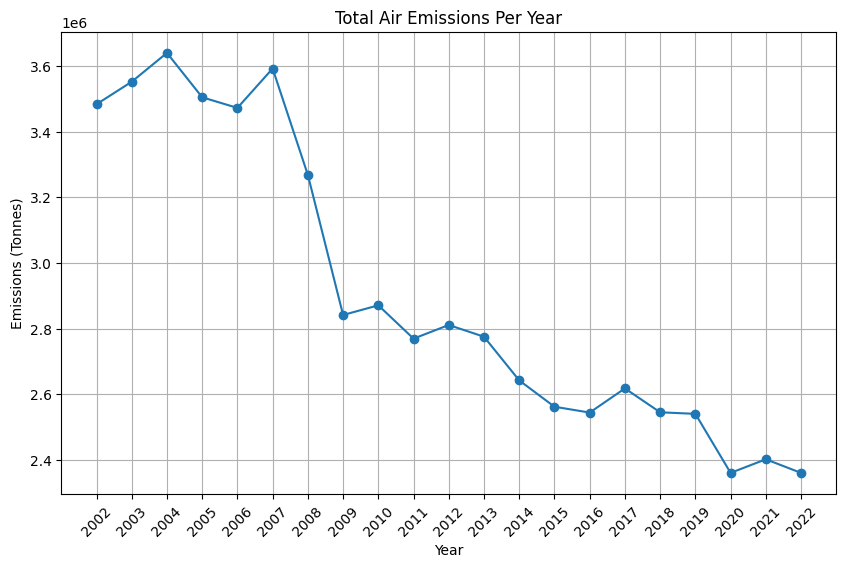

In [ ]:
import numpy as np

annual = df_clean.groupby('Reporting_Year')['Total_Air_Release'].sum().reset_index()
years = annual['Reporting_Year'].astype(int).values
tick_years = annual['Reporting_Year'].astype(int).unique()

plt.figure(figsize=(10,6))
plt.plot(annual['Reporting_Year'], annual['Total_Air_Release'], marker='o')

plt.title('Total Air Emissions Per Year')
plt.xlabel('Year')
plt.ylabel('Emissions (Tonnes)')

plt.xticks(tick_years, rotation=45)
plt.grid(True)
plt.show()

The yearly emissions trend shows a clear overall decline in total air emissions between 2002 and 2022. Emissions were highest in the early 2000s, reaching over 3.6 million tonnes, and gradually decreased to around 2.4 million tonnes by 2022. This downward trend suggests that environmental regulations, technological improvements, and cleaner industrial processes may be reducing emissions over time. Based on this pattern, it is reasonable to predict that total emissions will likely continue to decline gradually in the coming years, although occasional fluctuations may occur due to changes in industrial activity or economic conditions.

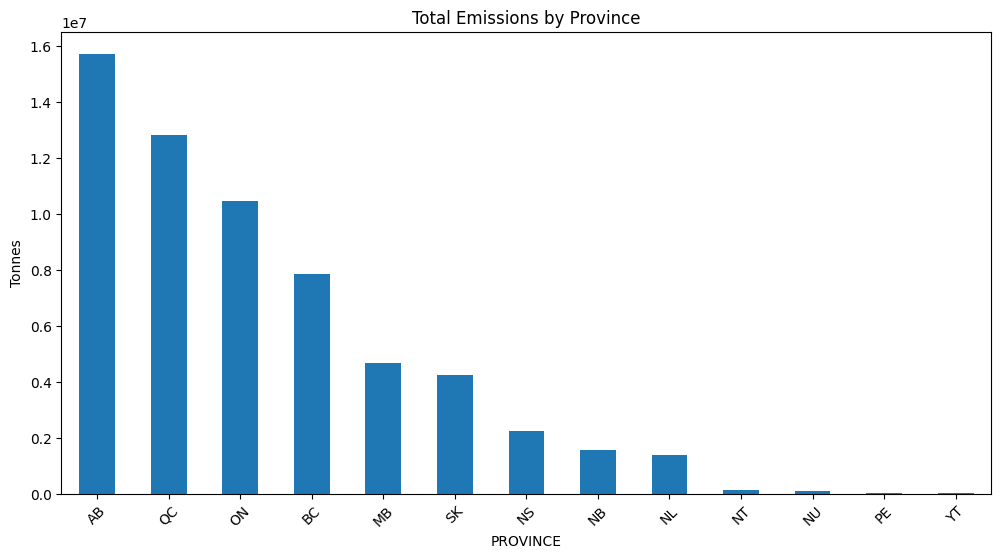

In [ ]:
province_totals = (df_clean.groupby('PROVINCE')['Total_Air_Release'].sum().sort_values(ascending=False))

plt.figure(figsize=(12,6))
province_totals.plot(kind='bar')
plt.title('Total Emissions by Province')
plt.ylabel('Tonnes')
plt.xticks(rotation=45)
plt.show()

Geographic analysis shows that emissions are heavily concentrated in certain provinces, particularly Alberta, Quebec, and Ontario. Alberta has the highest total emissions, which is likely due to its strong presence in energy production and oil sands extraction. Because these industries remain important to the Canadian economy, it is likely that Alberta will continue to be one of the largest contributors to national emissions in the future. However, improvements in emission control technologies may slowly reduce emissions per facility over time.

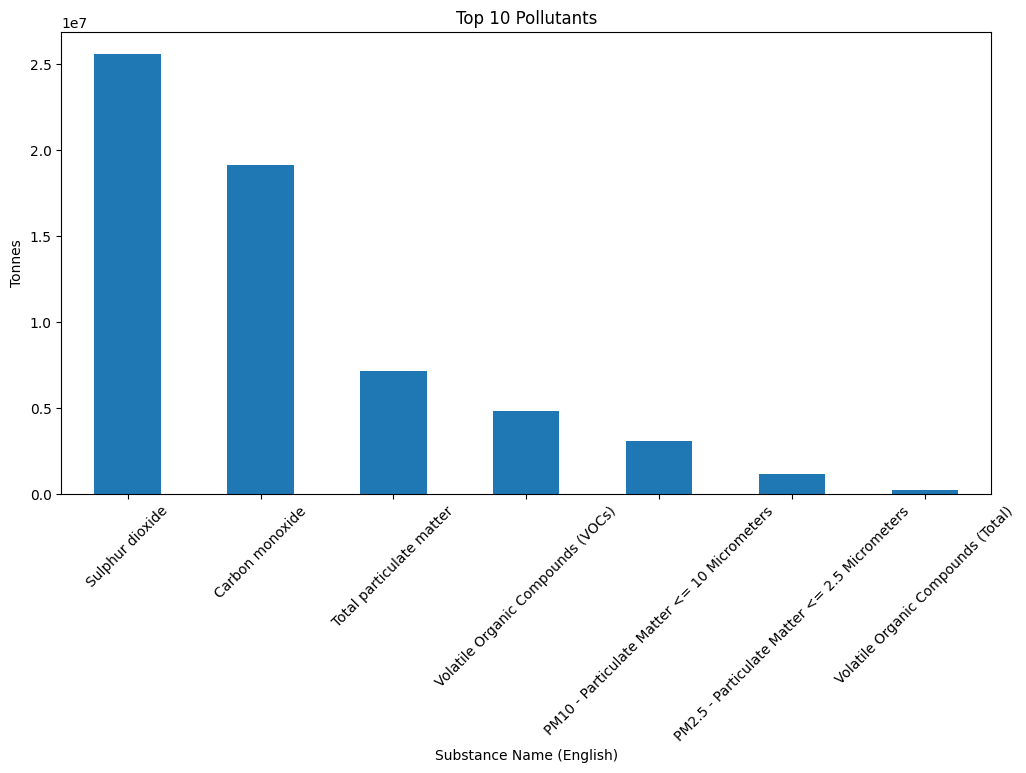

In [ ]:
top_substances = (df_clean.groupby('Substance Name (English)')['Total_Air_Release'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
top_substances.plot(kind='bar')
plt.title('Top 10 Pollutants')
plt.ylabel('Tonnes')
plt.xticks(rotation=45)
plt.show()

The pollutant analysis indicates that sulphur dioxide and carbon monoxide are the two largest contributors to air emissions. These pollutants are commonly associated with fossil fuel combustion and heavy industrial activities. Since many industrial sectors still rely on combustion-based processes, these pollutants are likely to remain dominant emission types. However, stricter environmental regulations and the transition toward cleaner energy sources may gradually reduce their levels.

In [ ]:
release_totals = df_clean[release_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
release_totals.plot(kind='bar')
plt.title("Total Emissions by Release Type")
plt.ylabel("Total Emissions")
plt.xticks(rotation=45)
plt.show()

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

The analysis of release types reveals that stack or point source emissions account for the majority of total emissions. This indicates that most pollutants originate from controlled industrial discharge points such as smokestacks rather than accidental releases or spills. Because industrial facilities will continue to operate using similar infrastructure, stack emissions are expected to remain the primary emission pathway in the near future unless major regulatory or technological changes significantly alter emission control systems.

In [ ]:
top_facilities = (df_clean.groupby('Facility_Name')['Total_Air_Release'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
top_facilities.plot(kind='bar')
plt.title("Top 10 Polluting Facilities")
plt.ylabel("Total Emissions (Tonnes)")
plt.xticks(rotation=60)
plt.show()

Facility-level analysis also shows that a small number of facilities contribute disproportionately to total emissions. Facilities such as Thompson Operations and Copper Cliff Smelter appear among the top emitters. This suggests that targeted emission reduction strategies focusing on the largest facilities could significantly reduce overall emissions. Therefore, future emission reductions may depend heavily on improvements or regulations applied to these major industrial sites.

In [ ]:
industry_totals = (df_clean.groupby('NAICS Title')['Total_Air_Release'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
industry_totals.plot(kind='bar')
plt.title("Top 10 Polluting Industries")
plt.ylabel("Total Emissions (Tonnes)")
plt.xticks(rotation=90)
plt.show()

industry-level analysis indicates that sectors such as primary aluminum production, fossil-fuel electric power generation, and non-ferrous metal smelting are responsible for the largest emissions. These industries involve energy-intensive processes that produce large amounts of air pollutants. As a result, these sectors will likely remain major emission sources in the near future. However, as renewable energy adoption increases and industrial processes become more efficient, emissions from these industries may gradually decrease.

Overall, by analyzing trends in time, geography, pollutants, facilities, and industry sectors, it is possible to make informed predictions about future emission patterns. The analysis suggests that emissions will likely continue to decline slowly overall, but will remain concentrated in certain provinces, industries, and major facilities unless significant technological or regulatory changes occur.